**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_copy = df_original.copy()
df_copy.drop(columns=['sii','PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [3]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [4]:
df = encoder_labels_categoriques(df_copy)

### Data preparation & Split

In [6]:
df.columns

Index(['Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-Height',
       'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
     

In [251]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [253]:
features = [
    "Basic_Demos-Age",
    "Basic_Demos-Sex",

    "CGAS-CGAS_Score",
    "SDS-SDS_Total_T",

    "Physical-Height",
    "Physical-Weight",
    "Physical-HeartRate",
    "Physical-Waist_Circumference",
    "Physical-Systolic_BP",

    "BIA-BIA_FMI",
    'BIA-BIA_BMC', 'BIA-BIA_BMI',
    'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
    'BIA-BIA_FFMI', 'BIA-BIA_Fat', 
    'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST',
    'BIA-BIA_TBW',
    "BIA-BIA_SMM",

    "FGC-FGC_CU",
    "FGC-FGC_PU",
    "FGC_Grip_Avg",
    "FGC_SitReach_Avg",
    
    "PreInt_EduHx-computerinternet_hoursday",

    "PAQ_Total"
]
target = "PCIAT-PCIAT_Total"

X = df[features]
y = df_original[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Total features: {X_train.shape[1]}")

Total features: 29


In [254]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [255]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


In [256]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R² score: 0.166
RMSE: 10.377


In [257]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                                   Feature  Coefficient
4                          Physical-Height     2.449437
3                          SDS-SDS_Total_T     2.058602
27  PreInt_EduHx-computerinternet_hoursday     1.697595
0                          Basic_Demos-Age     0.805985
23                              FGC-FGC_CU     0.658862
24                              FGC-FGC_PU     0.620114
6                       Physical-HeartRate     0.481594
11                             BIA-BIA_BMI     0.353696
18                             BIA-BIA_ICW     0.349635
19                             BIA-BIA_LDM     0.249906
10                             BIA-BIA_BMC     0.146752
8                     Physical-Systolic_BP     0.127618
14                             BIA-BIA_ECW     0.084937
21                             BIA-BIA_TBW     0.075073
5                          Physical-Weight     0.057391
22                             BIA-BIA_SMM     0.016480
20                             BIA-BIA_LST     0

In [258]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))

R²: 0.2142561863346577


In [ ]:
# Feature importance

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# sort descending
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df[:10]) # Top 10 features

                 Feature  Importance
3        SDS-SDS_Total_T    0.114782
0        Basic_Demos-Age    0.078025
2        CGAS-CGAS_Score    0.069077
28             PAQ_Total    0.064255
6     Physical-HeartRate    0.055809
8   Physical-Systolic_BP    0.053775
4        Physical-Height    0.046552
10           BIA-BIA_BMC    0.042007
5        Physical-Weight    0.038291
26      FGC_SitReach_Avg    0.037539


In [ ]:
#  SDS-SDS_Total_T = Sleep Disturbance Scale

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

### Models implementation

In [261]:
xgb_pipe = Pipeline([
    ("model", XGBRegressor(random_state=42))
])

param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [50, 100, 150],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [262]:
rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

### Trainning

In [263]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 150}


### Results 

In [264]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE RMSE     R2
Random Forest (Ottimizzato) 6.26 9.97 0.2300
      XGBoost (Ottimizzato) 6.38 9.93 0.2367


### Visualizzation

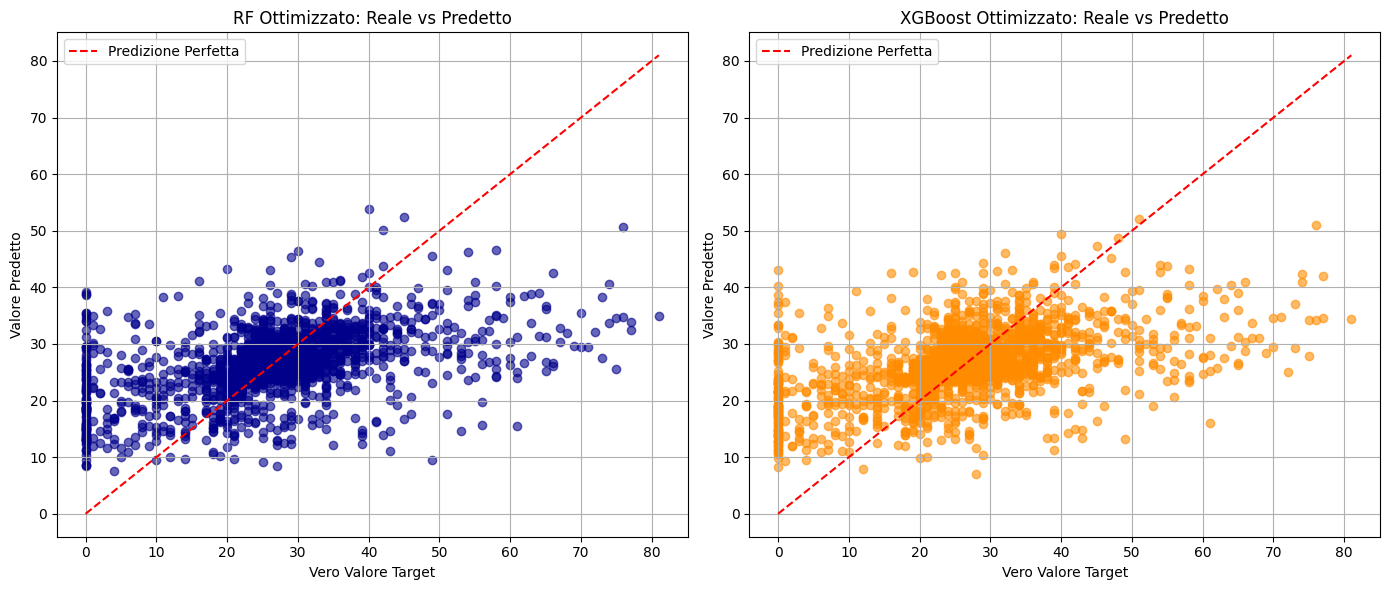

In [265]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Grafico Random Forest
plt.subplot(1, 2, 1)
plt.scatter(
    y_test, predizioni["Random Forest (Ottimizzato)"], alpha=0.6, color="darkblue"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predizione Perfetta",
)
plt.title("RF Ottimizzato: Reale vs Predetto")
plt.xlabel("Vero Valore Target")
plt.ylabel("Valore Predetto")
plt.grid(True)
plt.legend()

# Grafico XGBoost
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, predizioni["XGBoost (Ottimizzato)"], alpha=0.6, color="darkorange"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predizione Perfetta",
)
plt.title("XGBoost Ottimizzato: Reale vs Predetto")
plt.xlabel("Vero Valore Target")
plt.ylabel("Valore Predetto")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### New set of variable to predict Basic_Demos_Age

In [73]:
# Variables explicatives améliorées

features = [
    "Fitness_Endurance-Time_Sec",
    "FGC-FGC_GSD",
    "BIA-BIA_BMR",
    "BIA-BIA_FFM",
    "BIA-BIA_LST",
    "BIA-BIA_TBW",
    "PAQ_A-PAQ_A_Total",
    "Physical-Weight",
    "Physical-Height",
    "PreInt_EduHx-computerinternet_hoursday"
]

target = "Basic_Demos-Age"

# Drop NaN
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Total features: {X_train.shape[1]}")

Total features: 10


### Models implementation

In [74]:
xgb_pipe = Pipeline([
    ("model", XGBRegressor(random_state=42))
])

param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [50, 100, 150],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [75]:
rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

### Trainning

In [76]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 150}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 150}


### Results 

In [77]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE RMSE     R2
Random Forest (Ottimizzato) 1.47 2.14 0.6450
      XGBoost (Ottimizzato) 1.53 2.21 0.6213


### Visualizzation

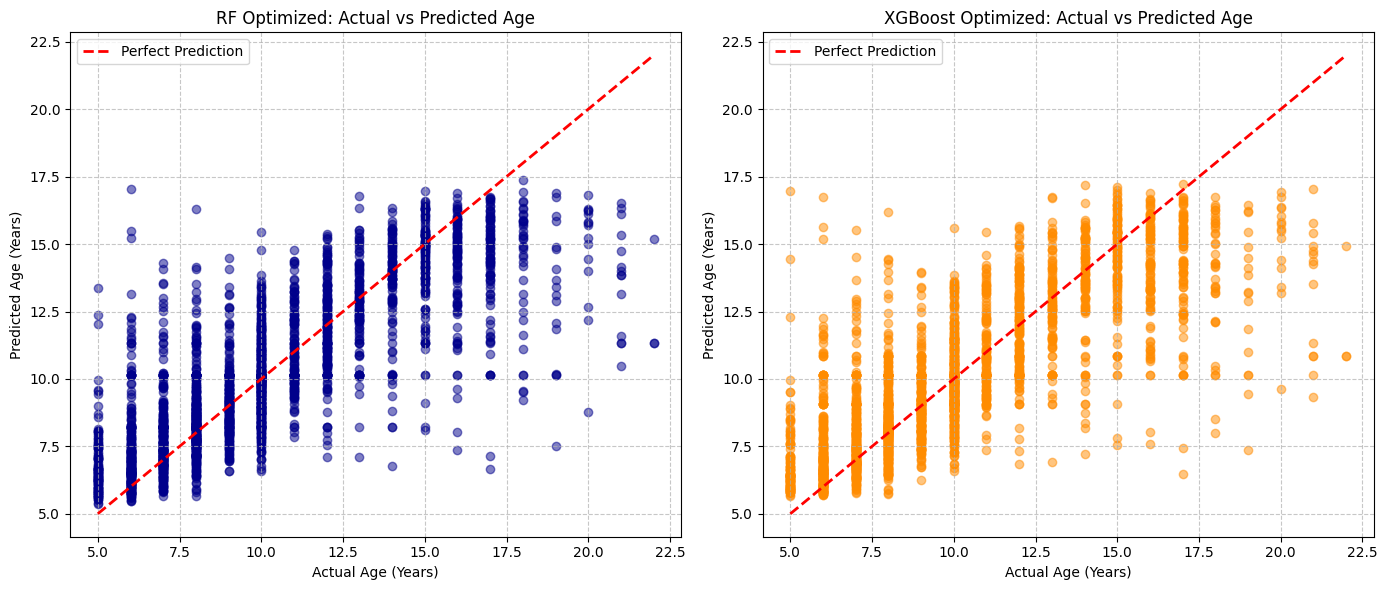

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Grafico 1: Random Forest
plt.subplot(1, 2, 1)
plt.scatter(
    y_test, predizioni["Random Forest (Ottimizzato)"], alpha=0.5, color="darkblue"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.title("RF Optimized: Actual vs Predicted Age")
plt.xlabel("Actual Age (Years)") 
plt.ylabel("Predicted Age (Years)") 
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# Grafico 2: XGBoost
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, predizioni["XGBoost (Ottimizzato)"], alpha=0.5, color="darkorange"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.title("XGBoost Optimized: Actual vs Predicted Age")
plt.xlabel("Actual Age (Years)") 
plt.ylabel("Predicted Age (Years)")  
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

##### Distribuzione dei Residui (Analisi dell'Errore)

Un grafico fondamentale per valutare un modello di regressione è lo studio dei residui (ovvero la differenza tra il valore reale e quello predetto: $y_{\text{vero}} - y_{\text{predetto}}$).
Se il modello è robusto, i residui devono distribuirsi come una campana gaussiana centrata sullo zero. Se ci sono asimmetrie, capiamo dove il modello sta sbagliando sistematicamente.

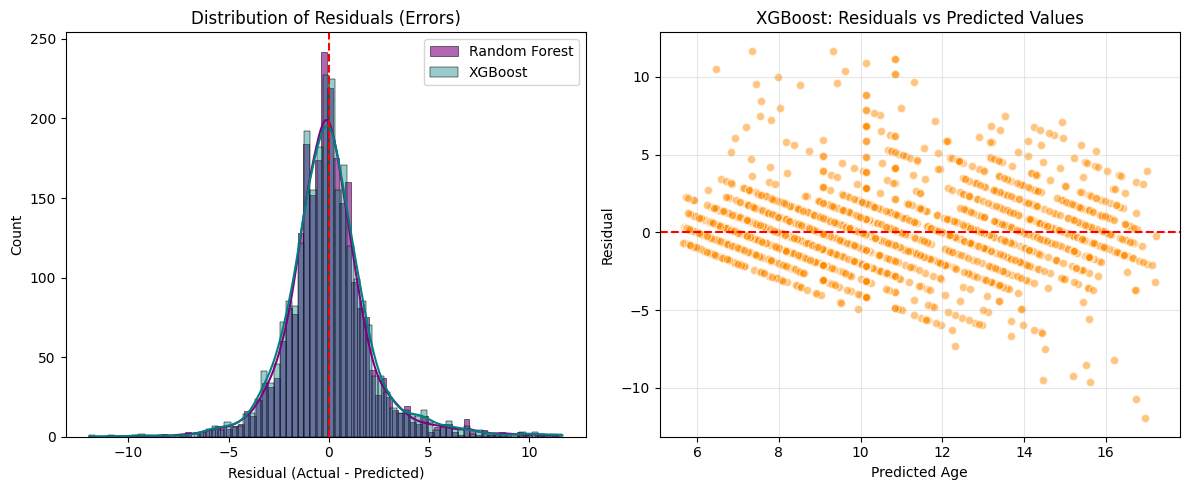

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcolo dei residui per entrambi i modelli
residui_rf = y_test - predizioni["Random Forest (Ottimizzato)"]
residui_xgb = y_test - predizioni["XGBoost (Ottimizzato)"]

plt.figure(figsize=(12, 5))

# Istogramma dei residui
plt.subplot(1, 2, 1)
sns.histplot(residui_rf, kde=True, color="purple", alpha=0.6, label="Random Forest")
sns.histplot(residui_xgb, kde=True, color="teal", alpha=0.4, label="XGBoost")
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()

# Scatter plot dei residui vs Valori Predetti (per vedere l'eteroschedasticità)
plt.subplot(1, 2, 2)
plt.scatter(
    predizioni["XGBoost (Ottimizzato)"],
    residui_xgb,
    alpha=0.5,
    color="darkorange",
    edgecolors="w",
)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("XGBoost: Residuals vs Predicted Values")
plt.xlabel("Predicted Age")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Variables explicatives améliorées

features = [
    "Fitness_Endurance-Time_Sec",
    "Physical-Weight",
    "Physical-Height",
    "PreInt_EduHx-computerinternet_hoursday"
    "Physical-Waist_Circumference"
]

target = "Basic_Demos-Age"

# Drop NaN
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Total features: {X_train.shape[1]}")

Total features: 10


In [ ]:
xgb_pipe = Pipeline([
    ("model", XGBRegressor(random_state=42))
])

param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [50, 100, 150],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [ ]:
rf_pipe = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [ ]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 150}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 150}


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE RMSE     R2
Random Forest (Ottimizzato) 1.50 2.20 0.6268
      XGBoost (Ottimizzato) 1.51 2.20 0.6272


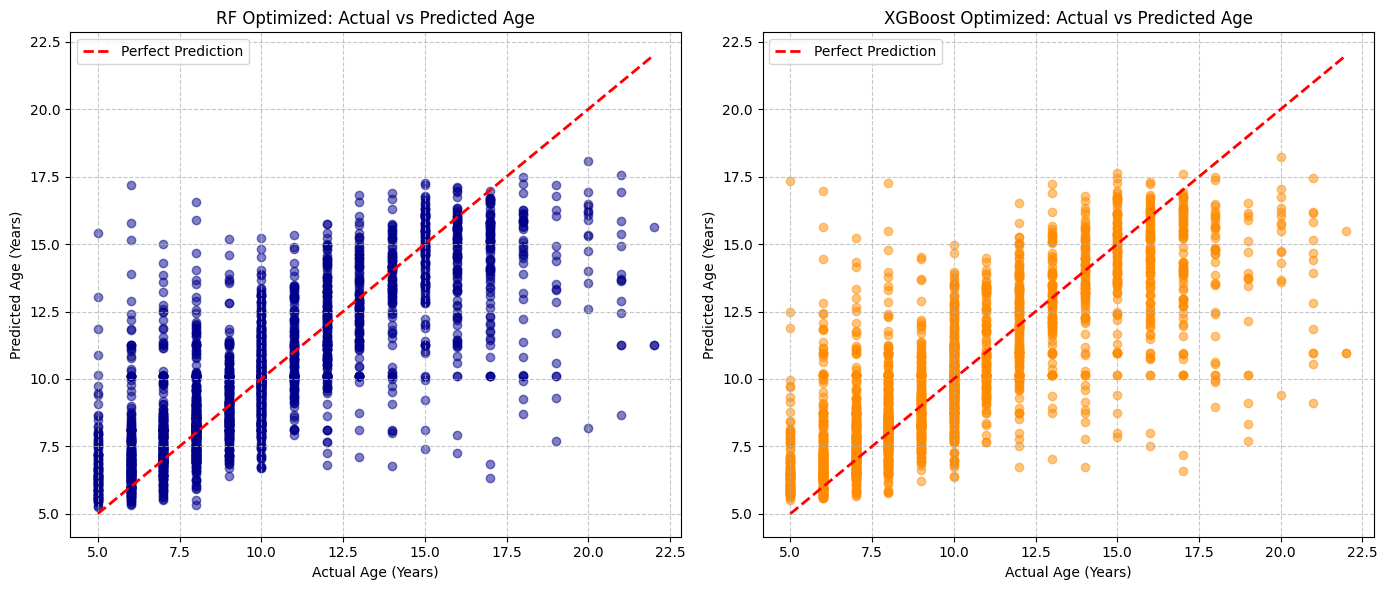

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Grafico 1: Random Forest
plt.subplot(1, 2, 1)
plt.scatter(
    y_test, predizioni["Random Forest (Ottimizzato)"], alpha=0.5, color="darkblue"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.title("RF Optimized: Actual vs Predicted Age")
plt.xlabel("Actual Age (Years)") 
plt.ylabel("Predicted Age (Years)") 
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# Grafico 2: XGBoost
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, predizioni["XGBoost (Ottimizzato)"], alpha=0.5, color="darkorange"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.title("XGBoost Optimized: Actual vs Predicted Age")
plt.xlabel("Actual Age (Years)") 
plt.ylabel("Predicted Age (Years)")  
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

**Key take away**

The baseline in this analysis was the simple linear regression model with the PCIAT-PCIAT_Total rebuild as target variable and the set features we consider was made by variables like demographic, physical activity and variables that explain how internet is impactfull in the life of young peoples not PCIAT-PCIAT_ from 01 to 20 to avoid data leakage. Then we analyzed the target with two advanced models of regression (XGBoostRegressor and RandomRoferstRegressor) at the end of our analysis we discover that the relation between the target and the set of features is not linear dependent because advanced non linear models were able to discover great relation with the target and the other models had interesting scores

NB: We selected PCIAT-PCIAT_Total because of the goal of the project (Problematic of internet use). Then we used Basic-Demos_Age as target, results were better and shwon that many features in the dataset are correleted with age but for the objective of the project is not that useful